# Week 5 Inventory Analysis 

In [164]:
# since the file is week5/notebook it is unable to access week4 so adding this to access all weeks
import os
import sys

project_root = os.path.abspath("../..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root added:", project_root)

Project root added: c:\Users\Kreesh\OneDrive\Desktop\Rippling\interneers-lab\backend\python


In [165]:
from week4.db_connection import initialize_mongo
from week4.models import Product, ProductCategory

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [166]:
initialize_mongo()
print("Database connected successfully")

Database connected successfully


## Fetch All Products

This cell runs a raw MongoEngine query to get all products directly from MongoDB.

In [167]:
products = Product.objects()
print("Total products:", products.count())
for product in products[:10]:
    print(product.to_dict())

Total products: 12
{'id': 2, 'name': 'Soap', 'description': 'Bath soap', 'price': '50.00', 'brand': 'Dove', 'quantity': 15, 'category': {'id': 1, 'title': 'Food', 'description': 'Daily grocery items', 'created_at': datetime.datetime(2026, 3, 22, 21, 54, 16, 429000), 'updated_at': datetime.datetime(2026, 3, 22, 21, 54, 16, 429000)}, 'category_id': 1, 'created_at': datetime.datetime(2026, 3, 22, 21, 56, 22, 840000), 'updated_at': datetime.datetime(2026, 3, 22, 21, 58, 55, 445000)}
{'id': 3, 'name': 'Rice', 'description': 'Basmati rice', 'price': '400.00', 'brand': 'India Gate', 'quantity': 10, 'category': {'id': 1, 'title': 'Food', 'description': 'Daily grocery items', 'created_at': datetime.datetime(2026, 3, 22, 21, 54, 16, 429000), 'updated_at': datetime.datetime(2026, 3, 22, 21, 54, 16, 429000)}, 'category_id': 1, 'created_at': datetime.datetime(2026, 3, 22, 22, 7, 6, 402000), 'updated_at': datetime.datetime(2026, 3, 22, 22, 7, 6, 402000)}
{'id': 5, 'name': 'Pan', 'description': 'Non-

## Fetch All Categories

This cell gets all product categories from MongoDB.

In [168]:
categories = ProductCategory.objects()
print("Total categories:", categories.count())
for category in categories[:5]:
    print(category.to_dict())

Total categories: 4
{'id': 1, 'title': 'Food', 'description': 'Daily grocery items', 'created_at': datetime.datetime(2026, 3, 22, 21, 54, 16, 429000), 'updated_at': datetime.datetime(2026, 3, 22, 21, 54, 16, 429000)}
{'id': 2, 'title': 'Electronics', 'description': 'Electronic products', 'created_at': datetime.datetime(2026, 3, 22, 21, 54, 27, 395000), 'updated_at': datetime.datetime(2026, 3, 22, 21, 54, 27, 394000)}
{'id': 3, 'title': 'Miscellaneous', 'description': 'Default category for uncategorized products', 'created_at': datetime.datetime(2026, 3, 22, 21, 56, 22, 835000), 'updated_at': datetime.datetime(2026, 3, 22, 21, 56, 22, 834000)}
{'id': 4, 'title': 'Kitchen', 'description': 'Kitchen items', 'created_at': datetime.datetime(2026, 3, 22, 22, 3, 25, 203000), 'updated_at': datetime.datetime(2026, 3, 22, 22, 3, 25, 203000)}


## Convert Product Data into a DataFrame

MongoEngine returns document objects.  
This cell converts product data into tabular form so it becomes easier to analyze and visualize.

In [169]:
rows = []
for product in products:
    rows.append({
        "id": product.id,
        "name": product.name,
        "description": product.description,
        "price": float(product.price),
        "brand": product.brand,
        "quantity": product.quantity,
        "category": product.category.title if product.category else "No Category"
    })
df = pd.DataFrame(rows)
df

,id,name,description,price,brand,quantity,category
0,2,Soap,Bath soap,50.0,Dove,15,Food
1,3,Rice,Basmati rice,400.0,India Gate,10,Food
2,5,Pan,Non-stick pan,999.0,Prestige,5,Electronics
3,6,Soap,Bath soap,45.0,Dove,20,Miscellaneous
4,69c76070d11850d8ae737d65,Test Product 1,No category no brand,100.0,Unknown,5,Miscellaneous
5,69c76078d11850d8ae737d67,Test Product 2,No category but has brand,200.0,Nike,10,Miscellaneous
6,69c7607ed11850d8ae737d69,Test Product 3,Has category but no brand,150.0,Unknown,8,Miscellaneous
7,69c7728dd11850d8ae737d6c,Legacy Product 1,Missing category only,100.0,Nike,5,Miscellaneous
8,69c77295d11850d8ae737d6e,Legacy Product 2,Missing brand only,120.0,Unknown,8,Miscellaneous
9,69c772a8d11850d8ae737d70,Legacy Product 3,Missing both brand and category,150.0,Unknown,10,Miscellaneous


## Basic Data Inspection

This helps us understand the structure of the inventory dataset.

In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           12 non-null     object 
 1   name         12 non-null     object 
 2   description  12 non-null     object 
 3   price        12 non-null     float64
 4   brand        12 non-null     object 
 5   quantity     12 non-null     int64  
 6   category     12 non-null     object 
dtypes: float64(1), int64(1), object(5)
memory usage: 804.0+ bytes


In [171]:
df.describe(include="all")

,id,name,description,price,brand,quantity,category
count,12.0,12,12,12.000000,12,12.000000,12
unique,12.0,10,11,NaN,6,NaN,4
top,2.0,Soap,Bath soap,NaN,Unknown,NaN,Miscellaneous
freq,1.0,2,2,NaN,4,NaN,8
mean,NaN,NaN,NaN,292.833333,NaN,9.333333,NaN
std,NaN,NaN,NaN,342.837049,NaN,4.696872,NaN
min,NaN,NaN,NaN,45.000000,NaN,4.000000,NaN
25%,NaN,NaN,NaN,100.000000,NaN,5.000000,NaN
50%,NaN,NaN,NaN,150.000000,NaN,9.000000,NaN
75%,NaN,NaN,NaN,250.000000,NaN,10.500000,NaN


## Category-wise Product Count

This counts how many products belong to each category.

In [172]:
df["category"].value_counts()

category
Miscellaneous    8
Food             2
Electronics      1
Kitchen          1
Name: count, dtype: int64

## Total Stock by Category using Matplotlib

This shows the total available quantity for each category.

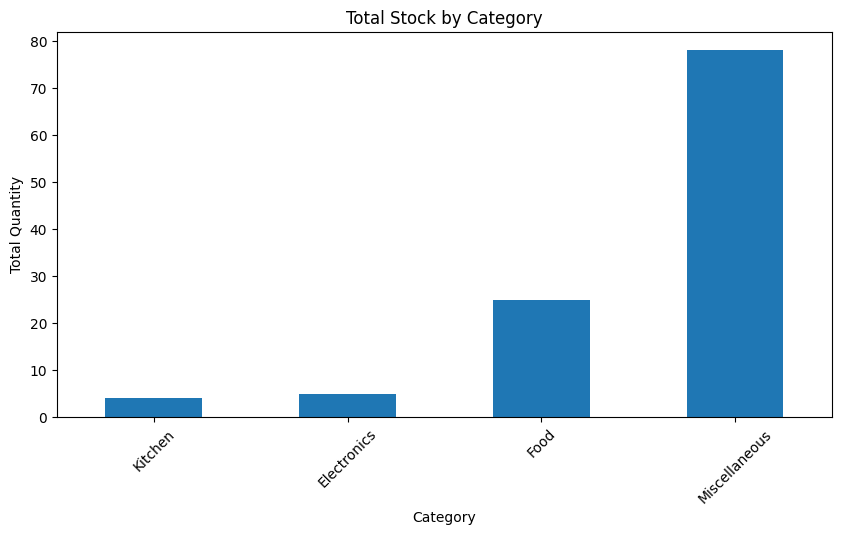

In [173]:
category_stock = df.groupby("category")["quantity"].sum().sort_values()
plt.figure(figsize=(10,5))
category_stock.plot(kind="bar")
plt.title("Total Stock by Category")
plt.xlabel("Category")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.show()

## Total Stock by Category using Seaborn

This visualizes the same stock information using seaborn.

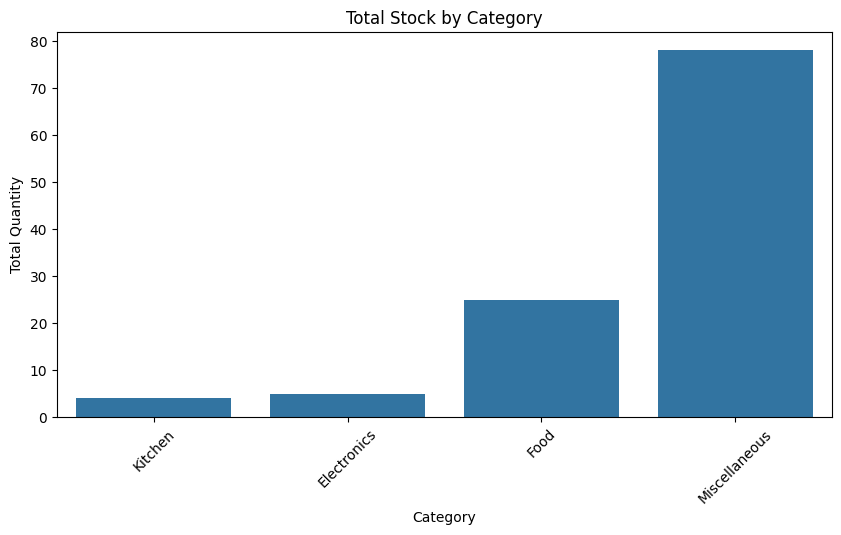

In [174]:
plt.figure(figsize=(10, 5))
sns.barplot(x=category_stock.index, y=category_stock.values)
plt.title("Total Stock by Category")
plt.xlabel("Category")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.show()

## Low Stock Products

This identifies products whose quantity is below 5.

In [175]:
low_stock_rows = []
for index,row in df.iterrows():
    if row["quantity"]<5:
        low_stock_rows.append(row)

low_stock_df = pd.DataFrame(low_stock_rows)
print("Number of low-stock products:", len(low_stock_df))
low_stock_df

Number of low-stock products: 1


,id,name,description,price,brand,quantity,category
11,8,Pan,cooking pan,1000.0,prestige,4,Kitchen


## Conclusion

This notebook demonstrates:

- raw MongoEngine queries using `Product.objects()` and `ProductCategory.objects()`
- conversion of MongoDB documents into a pandas DataFrame
- category-wise inventory analysis
- stock visualization using matplotlib and seaborn
- identification of low-stock products